In [29]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

# Importing Model Data
check=False
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'

# # dx = 1 km; Np = 1M; Nt = 5 min
# data=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_1km_5min.nc') #***
# parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_1km_5min_1e6.nc') #***
# res='1km';t_res='5min'
# Np_str='1e6'

# # dx = 1km; Np = 50M
# #Importing Model Data
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_1km_1min.nc') #***
# parcel=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_50M.nc') #***
# res='1km'; t_res='1min'; Np_str='50e6'

# dx = 1km; Np = 50M; Nz = 95
#Importing Model Data
dir2='/home/air673/koa_scratch/'
data=xr.open_dataset(dir2+'cm1out_1km_1min_95nz.nc') #***
parcel=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_95nz.nc') #***
res='1km'; t_res='1min_95nz'; Np_str='50e6'

In [30]:
times=data['time'].values/(1e9 * 60); times=times.astype(float);
minutes=1/times[1] #1 / minutes per timestep = timesteps per minute
index_adjust=0
ocean_fraction=0.25

In [31]:
import sys
dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
path=dir2+'../Functions/'
sys.path.append(path)

import NumericalFunctions
from NumericalFunctions import * # import NumericalFunctions 
import PlottingFunctions
from PlottingFunctions import * # import PlottingFunctions


# # Get all functions in NumericalFunctions
# import inspect
# functions = [f[0] for f in inspect.getmembers(NumericalFunctions, inspect.isfunction)]
# functions

In [32]:
#LIMITING Y AXIS
# limit_y=True
limit_y=False

In [33]:
#NEEDED TO PLOT THE CORRECT DATA #*#*
data_type="Tracked_Properties"

In [34]:
# #OLD
# #READING BACK IN

# types = ["ALL", "SHALLOW", "DEEP"]
# variables = ["W", "QV", "QCQI", "TH", "TH_E", "BUOYANCY", "HMC"]

# vars_list = []
# SE_list = []

# for t in types:
#     for var in variables:
#         vars_list.append(f"CL_{t}_profile_array_{var.upper()}")
#         vars_list.append(f"nonCL_{t}_profile_array_{var.upper()}")
# # for t in types:
# #     for var in variables:
# #         SE_list.append(f"CL_{t}_SE_{var.upper()}")
# #         SE_list.append(f"nonCL_{t}_SE_{var.upper()}")

# # Define directory and output file path
# dir2=dir+'Project_Algorithms/Tracked_Profiles/job_out2/'
# # input_file=dir2+f"CL_nonCL_tracked_profiles_SE_{res}_{t_res}_{Np_str}.h5"
# input_file=dir2+f"CL_nonCL_tracked_profiles_{res}_{t_res}_{Np_str}.h5"

# # Open the HDF5 file and read the stored datasets into dynamically named variables
# with h5py.File(input_file, 'r') as f:
#     for var in vars_list: #+ SE_list:
#         globals()[var] = f[f'{var.upper()}'][:]

In [35]:
type1='CL';type2='nonCL'
dir3=dir+'Project_Algorithms/Tracked_Profiles/OUTPUT_FILES/'
filePath=dir3+f"{data_type}_"+f"{type1}_{type2}_tracked_profiles_{res}_{t_res}_{Np_str}.h5"
with h5py.File(filePath, 'r') as h5f:
    for key in h5f.keys():
        globals()[key] = h5f[key][:]
        # print(key)

In [36]:
# type1='CL';type2='nonCL'
# dir3=dir+'Project_Algorithms/Tracked_Profiles/OUTPUT_FILES/'
# filePath=dir3+f"{data_type}_"+f"{type1}_{type2}_tracked_profiles_SE_{res}_{t_res}_{Np_str}.h5"
# with h5py.File(filePath, 'r') as h5f:
#     for key in h5f.keys():
#         globals()[key] = h5f[key][:]
#         # print(key)

In [37]:
##################################
#PLOTTING

In [38]:
def LoadAllCloudBase():
    dir2 = dir + f'Project_Algorithms/Tracking_Algorithms/'
    in_file = dir2 + f"all_cloudbase_{res}_{t_res}_{Np_str}.pkl"
    with open(in_file, 'rb') as f:
        all_cloudbase = pickle.load(f)
    return(all_cloudbase)
min_all_cloudbase=np.nanmin(LoadAllCloudBase())
all_cloudbase=min_all_cloudbase
print(f"Minimum Cloudbase is: {min_all_cloudbase}\n")

Minimum Cloudbase is: 1.225000023841858



In [39]:
def averaged_profiles(profile):
    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data\n"
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

In [40]:
def averaged_profile_SE(profile): 

    ######################################## (MOVED TO SE_averaged_profilesssFUNCTION)
    mask=np.where(profile[:,1]!=0)
    
    #DIVIDE BY N = n-1
    with np.errstate(divide='ignore', invalid='ignore'):
        profile[mask, 0] /= (profile[mask, 1]-1) 
    #TAKE THE SQUARE ROOT
    profile[mask,0]=np.sqrt(profile[mask,0]) 
    #DIVIDE BY SQUARE ROOT OF n ==> STANDARD ERROR
    profile[mask, 0] /= np.sqrt(profile[mask, 1]) 

    #SETTING TO NAN WHERE UNDEFINED
    where_undefined=np.where(profile[:,1]==1)
    profile[where_undefined,0]=np.nan #=0
    ########################################
    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    SE=out_var[:, 0]
    zlevels=out_var[:, 2]
    return SE,zlevels



In [41]:
# List of variables with their corresponding labels and x-axis titles
var_units = [
    ("w", 'w (m/s)'),
    ("qv", r"$q_v$ (g/kg)"),
    ("qcqi", r"$q_c+q_i$ (g/kg)"),
    ("th", r"$\theta$ (K)"),
    ("th_e", r"$\theta_e$ (K)"),
    ("buoyancy", r"Buoyancy $(m/s^2)$"),
    ("hmc", "HMC (g/kg/s)"),
]

In [42]:
SE_ARRAYS=False
# SE_ARRAYS=True

if SE_ARRAYS==False:
    #IF NOT USING SE ARRAYS
    for type2 in ['ALL','SHALLOW','DEEP']:
        for type1 in ['CL','nonCL','SBZ','nonSBZ','ColdPool']:
            for var in [var_unit[0] for var_unit in var_units]: 
                globals()[f"{type1}_{type2}_profile_array_SE_{var.upper()}"]=np.zeros_like(CL_ALL_profile_array_W[:,0:3])

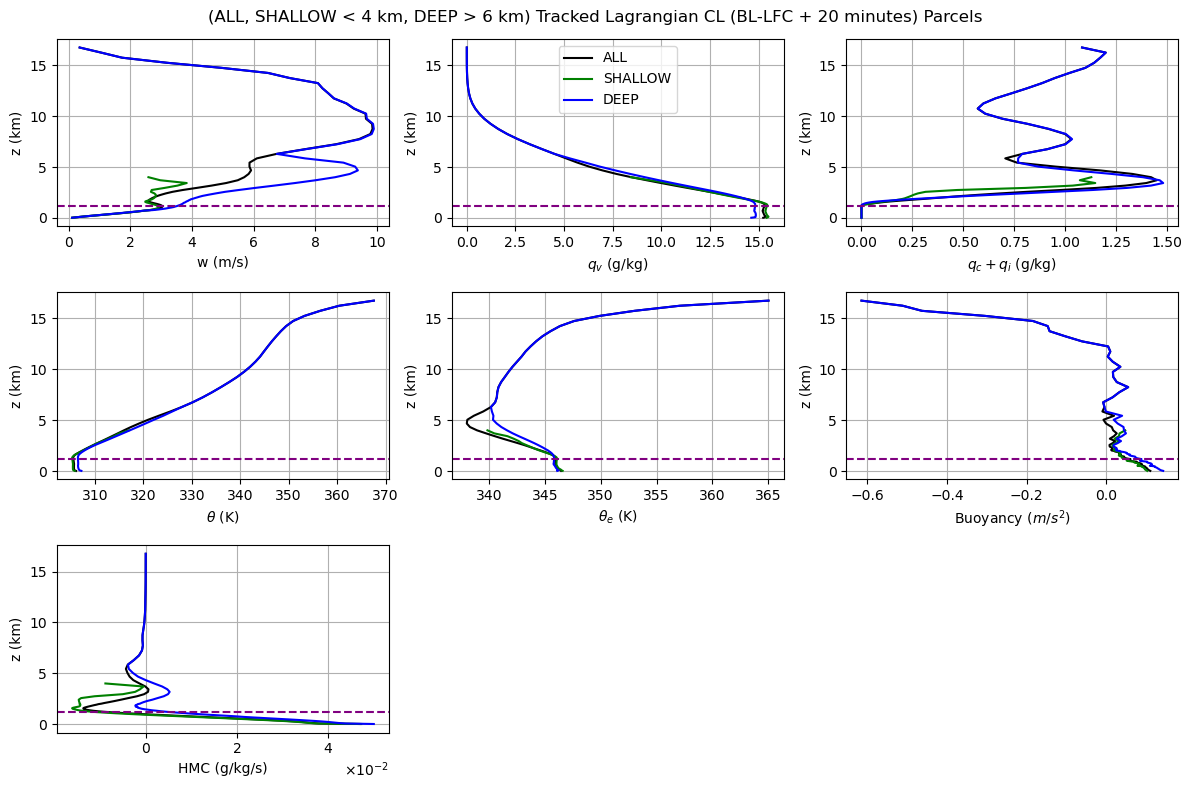

In [46]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

profiles = []
SE_profiles = []
for var, label in var_units:
    profiles.append((
        globals()[f"CL_ALL_profile_array_{var.upper()}"].copy(),
        globals()[f"CL_SHALLOW_profile_array_{var.upper()}"].copy(),
        globals()[f"CL_DEEP_profile_array_{var.upper()}"].copy(),
        label
    ))
    
    SE_profiles.append((
        globals()[f"CL_ALL_profile_array_SE_{var.upper()}"].copy(),
        globals()[f"CL_SHALLOW_profile_array_SE_{var.upper()}"].copy(),
        globals()[f"CL_DEEP_profile_array_SE_{var.upper()}"].copy(),
        None  # placeholder for xlabel not used in SE
    ))

# Set up the 2x3 gridspec
fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(3, 3, figure=fig)

# Loop through the profiles and plot them on subplots
# for i, (ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel) in enumerate(profiles):
for i, ((ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel), (ALL_SE, SHALLOW_SE, DEEP_SE, _)) in enumerate(zip(profiles, SE_profiles)):
    ax = fig.add_subplot(gs[i])
 
    # Plot Profiles
    profile_list=[ALL_profile_array,SHALLOW_profile_array,DEEP_profile_array]
    SE_profile_list=[ALL_SE,SHALLOW_SE,DEEP_SE]
    colors=['black','green','blue']
    labels=['ALL','SHALLOW','DEEP']
    # for (profile,color,label) in zip(profile_list,colors,labels):   
    for (profile,SE_profile,color,label) in zip(profile_list,SE_profile_list,colors,labels):   
        profile=averaged_profiles(profile) # Compute the averaged profile
        
        
        ################################################
        SE=averaged_profile_SE(SE_profile) #***
        switch=1
        if xlabel in [r'$q_v$ (g/kg)',r'$q_c+q_i$ (g/kg)','HMC (g/kg/s)']:
            profile[:,0]*=1000
            SE_profile[:,0]*=1000
            switch=0
        #STANDARD ERROR SHADING
        if SE_ARRAYS==True:
            ax.fill_betweenx(profile[:, 1], profile[:, 0] - 1.96*SE[0]*switch, profile[:, 0] + 1.96*SE[0], color=color, alpha=0.1) #***
        ################################################
        
        ax.plot(profile[:, 0], profile[:, 1],color=color,label=label)
        
    ax.set_xlabel(xlabel)
    ax.set_ylabel('z (km)')
    ax.grid(True)

    #LEGEND
    if i==1:
        ax.legend(loc='upper center')

    if i==6:
        apply_scientific_notation([ax])
        
    #LIMITING YAXIS TO BELOW 3 KM
    if limit_y==True: ax.set_ylim(0,3)

#MEAN CLOUD BASE
axs = fig.get_axes()
ax1, ax2, ax3, ax4, ax5, ax6, ax7 = axs
for axis in [ax1,ax2,ax3,ax4,ax5,ax6,ax7]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')
 
#LEGEND
# legend_ax = fig.add_subplot(gs[1, 2])  # Use the (2, 3) grid slot for the legend
# legend_ax.axis("off")  # Hide axes for the legend box
# legend_ax.legend(*ax.get_legend_handles_labels(), loc='center', frameon=False)

#ACCESSORIES
plt.suptitle('(ALL, SHALLOW < 4 km, DEEP > 6 km) Tracked Lagrangian CL (BL-LFC + 20 minutes) Parcels')
plt.tight_layout()

# #MATCHING X AXISES WITH NEXT PLOT
# #(TO KEEP AXISES CONSISTENT RUN PLOTS IN ORDER: 1st Plots, 2nd Plots, 1st Plots)
# for axis in axs:
#     nbins=7;axis.xaxis.set_major_locator(MaxNLocator(nbins=nbins))
# if 'ax8' in globals():
#     fix_x_limits([ax1,ax8])
#     fix_x_limits([ax2,ax9])
#     fix_x_limits([ax3,ax10])
#     fix_x_limits([ax4,ax11])
#     fix_x_limits([ax5,ax12])
#     fix_x_limits([ax6,ax13])
#     fix_x_limits([ax7,ax14])
#     del ax1,ax2,ax3,ax4,ax5,ax6,ax7,ax8,ax9,ax10,ax11,ax12,ax13,ax14


In [166]:
#TESTING
# profiles = []
# for var, label in var_units:
#     profiles.append((
#         globals()[f"CL_ALL_profile_array_{var.upper()}"].copy(),
#         globals()[f"CL_SHALLOW_profile_array_{var.upper()}"].copy(),
#         globals()[f"CL_DEEP_profile_array_{var.upper()}"].copy(),
#         label
#     ))

# # Set up the 2x3 gridspec
# fig = plt.figure(figsize=(12, 8))
# gs = gridspec.GridSpec(3, 3, figure=fig)

# for i, (ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel) in enumerate(profiles):
#     ax = fig.add_subplot(gs[i])
 
#     # Plot Profiles
#     profile_list=[ALL_profile_array,SHALLOW_profile_array,DEEP_profile_array]
#     colors=['black','green','blue']
#     labels=['ALL','SHALLOW','DEEP']
#     for (profile,color,label) in zip(profile_list,colors,labels):   
#         ax.plot(profile[:, 1], profile[:, 2],color=color,label=label)
        
#     ax.set_xlabel(xlabel)
#     ax.set_ylabel('z (km)')
#     ax.grid(True)

#     #LEGEND
#     if i==1:
#         ax.legend(loc='upper center')

#     if i==6:
#         apply_scientific_notation([ax])
        
#     #LIMITING YAXIS TO BELOW 10 KM
#     ax.set_ylim(0,10)

# ###############################################################


# #MEAN CLOUD BASE
# axs = fig.get_axes()
# ax1, ax2, ax3, ax4, ax5, ax6, ax7 = axs
# for axis in [ax1,ax2,ax3,ax4,ax5,ax6,ax7]:
#     axis.axhline(all_cloudbase,color='purple',linestyle='dashed')
 
# #LEGEND
# # legend_ax = fig.add_subplot(gs[1, 2])  # Use the (2, 3) grid slot for the legend
# # legend_ax.axis("off")  # Hide axes for the legend box
# # legend_ax.legend(*ax.get_legend_handles_labels(), loc='center', frameon=False)

# #ACCESSORIES
# plt.suptitle('(ALL, SHALLOW < 4 km, DEEP > 6 km) Tracked Lagrangian CL (BL-LFC + 20 minutes) Parcels')
# plt.tight_layout()


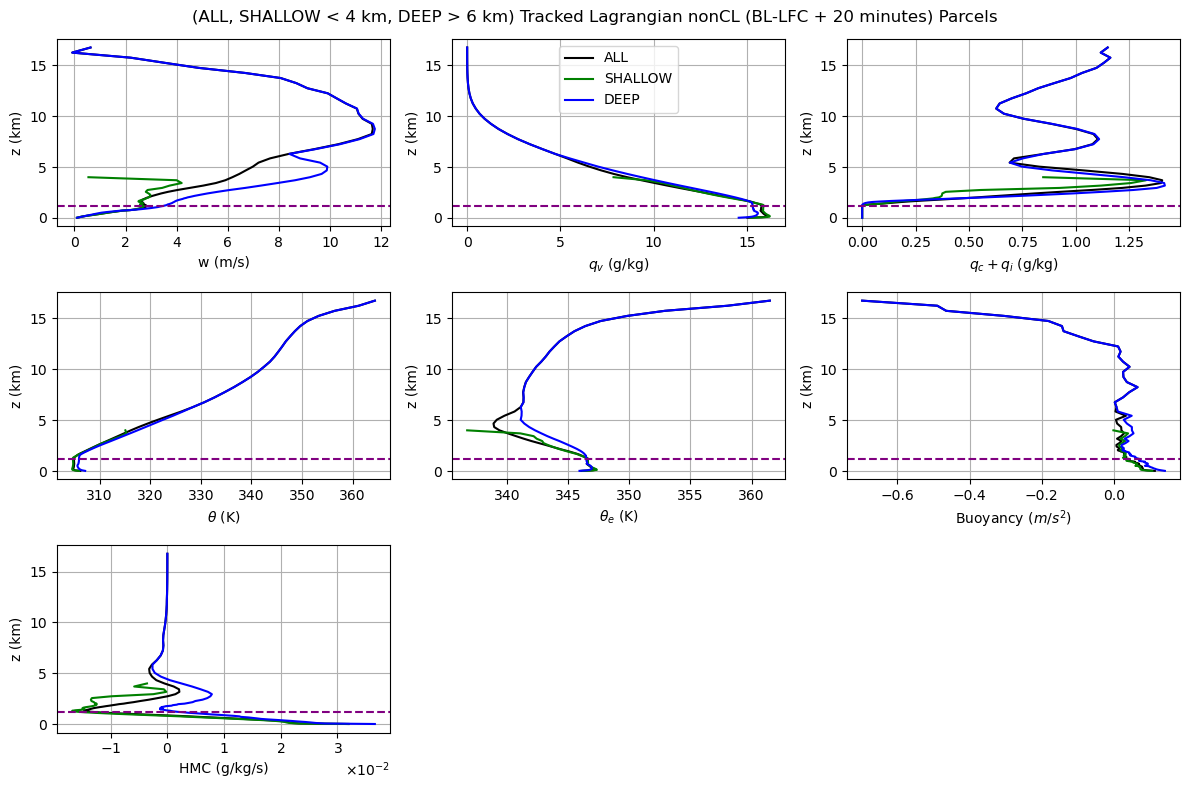

In [47]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

profiles = []
SE_profiles = []
for var, label in var_units:
    profiles.append((
        globals()[f"nonCL_ALL_profile_array_{var.upper()}"].copy(),
        globals()[f"nonCL_SHALLOW_profile_array_{var.upper()}"].copy(),
        globals()[f"nonCL_DEEP_profile_array_{var.upper()}"].copy(),
        label
    ))
    
    SE_profiles.append((
        globals()[f"nonCL_ALL_profile_array_SE_{var.upper()}"].copy(),
        globals()[f"nonCL_SHALLOW_profile_array_SE_{var.upper()}"].copy(),
        globals()[f"nonCL_DEEP_profile_array_SE_{var.upper()}"].copy(),
        None  # placeholder for xlabel not used in SE
    ))

# Set up the 2x3 gridspec
fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(3, 3, figure=fig)

# Loop through the profiles and plot them on subplots
# for i, (ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel) in enumerate(profiles):
for i, ((ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel), (ALL_SE, SHALLOW_SE, DEEP_SE, _)) in enumerate(zip(profiles, SE_profiles)):
    ax = fig.add_subplot(gs[i])
 
    # Plot Profiles
    profile_list=[ALL_profile_array,SHALLOW_profile_array,DEEP_profile_array]
    SE_profile_list=[ALL_SE,SHALLOW_SE,DEEP_SE]
    colors=['black','green','blue']
    labels=['ALL','SHALLOW','DEEP']
    # for (profile,color,label) in zip(profile_list,colors,labels):   
    for (profile,SE_profile,color,label) in zip(profile_list,SE_profile_list,colors,labels):   
        profile=averaged_profiles(profile) # Compute the averaged profile
        
        
        ################################################
        SE=averaged_profile_SE(SE_profile) #***
        switch=1
        if xlabel in [r'$q_v$ (g/kg)',r'$q_c+q_i$ (g/kg)','HMC (g/kg/s)']:
            profile[:,0]*=1000
            SE_profile[:,0]*=1000
            switch=0
        #STANDARD ERROR SHADING
        if SE_ARRAYS==True:
            ax.fill_betweenx(profile[:, 1], profile[:, 0] - 1.96*SE[0]*switch, profile[:, 0] + 1.96*SE[0], color=color, alpha=0.1) #***
        ################################################
        
        ax.plot(profile[:, 0], profile[:, 1],color=color,label=label)
        
    ax.set_xlabel(xlabel)
    ax.set_ylabel('z (km)')
    ax.grid(True)

    #LEGEND
    if i==1:
        ax.legend(loc='upper center')

    if i==6:
        apply_scientific_notation([ax])
        
    #LIMITING YAXIS TO BELOW 3 KM
    if limit_y==True: ax.set_ylim(0,3)


#MEAN CLOUD BASE
axs = fig.get_axes()
ax1, ax2, ax3, ax4, ax5, ax6, ax7 = axs
for axis in [ax1,ax2,ax3,ax4,ax5,ax6,ax7]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')
 
#LEGEND
# legend_ax = fig.add_subplot(gs[1, 2])  # Use the (2, 3) grid slot for the legend
# legend_ax.axis("off")  # Hide axes for the legend box
# legend_ax.legend(*ax.get_legend_handles_labels(), loc='center', frameon=False)

#ACCESSORIES
plt.suptitle('(ALL, SHALLOW < 4 km, DEEP > 6 km) Tracked Lagrangian nonCL (BL-LFC + 20 minutes) Parcels')
plt.tight_layout()

# #MATCHING X AXISES WITH NEXT PLOT
# #(TO KEEP AXISES CONSISTENT RUN PLOTS IN ORDER: 1st Plots, 2nd Plots, 1st Plots)
# for axis in axs:
#     nbins=7;axis.xaxis.set_major_locator(MaxNLocator(nbins=nbins))
# if 'ax8' in globals():
#     fix_x_limits([ax1,ax8])
#     fix_x_limits([ax2,ax9])
#     fix_x_limits([ax3,ax10])
#     fix_x_limits([ax4,ax11])
#     fix_x_limits([ax5,ax12])
#     fix_x_limits([ax6,ax13])
#     fix_x_limits([ax7,ax14])
#     del ax1,ax2,ax3,ax4,ax5,ax6,ax7,ax8,ax9,ax10,ax11,ax12,ax13,ax14


In [48]:
#DIFFERENCES

def average_difference(array1, array2):
    out_var_one=averaged_profiles(array1)
    out_var_two=averaged_profiles(array2)

    #masking out non matches
    second_col_one = out_var_one[:, 1]
    second_col_two = out_var_two[:, 1]
    mask_one = np.isin(second_col_one, second_col_two)
    mask_two = np.isin(second_col_two, second_col_one)
    
    out_var_one = out_var_one.copy()[mask_one]
    out_var_two = out_var_two.copy()[mask_two]
    
    diff=(out_var_one[:,0]-out_var_two[:,0])
    zs=out_var_one[:,1]

    out_profile=np.zeros((len(diff),2))

    out_profile[:,0]=diff;out_profile[:,1]=zs;
    return out_profile

var_names = [var[0] for var in var_units]
categories = ["ALL", "SHALLOW", "DEEP"]

for var in var_names:
    for cat in categories:
        # Construct the variable names dynamically
        CL_profile = globals()[f"CL_{cat}_profile_array_{var.upper()}"]
        nonCL_profile = globals()[f"nonCL_{cat}_profile_array_{var.upper()}"]
        
        # Calculate the difference and assign it to the global variable
        globals()[f"{cat}_diff_{var.upper()}"] = average_difference(CL_profile, nonCL_profile)
print('done')

done


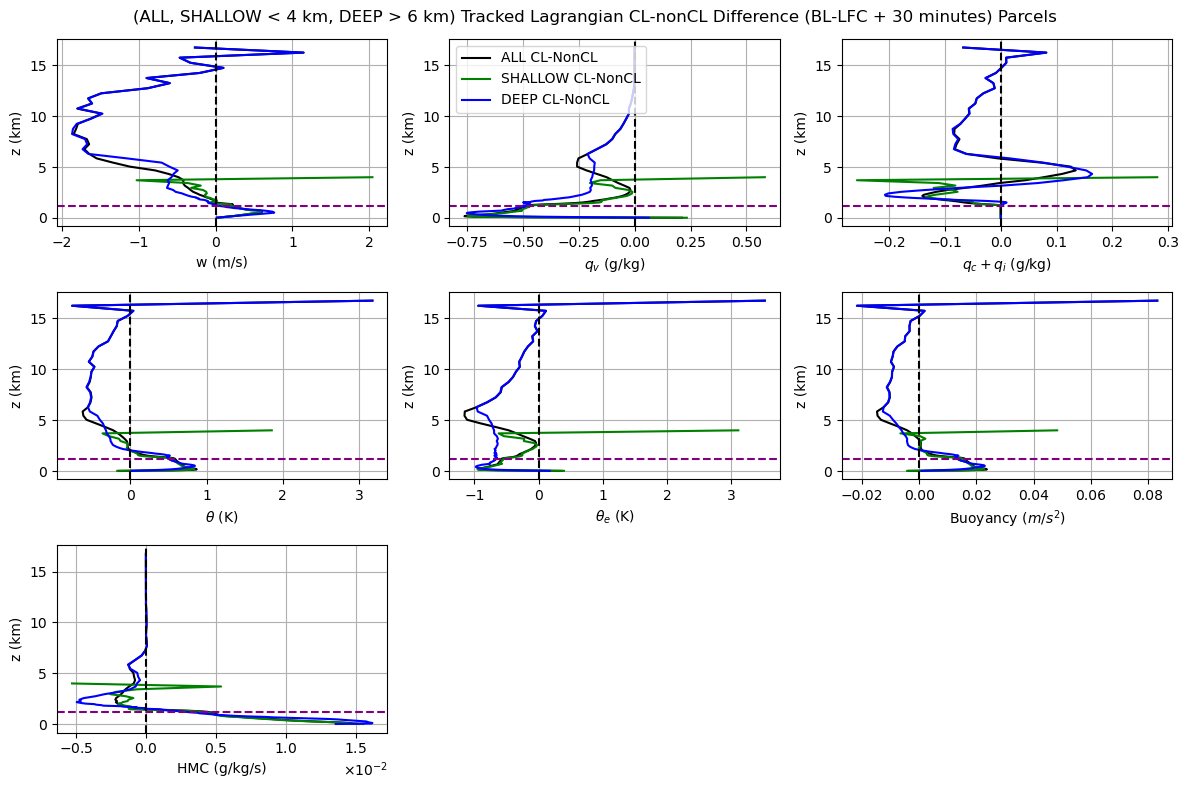

In [49]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Construct profiles dynamically using globals()
profiles = [
    (
        globals()[f"ALL_diff_{var.upper()}"].copy(),
        globals()[f"SHALLOW_diff_{var.upper()}"].copy(),
        globals()[f"DEEP_diff_{var.upper()}"].copy(),
        label
    )
    for var, label in var_units
]

# Set up the 2x3 gridspec
fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(3, 3, figure=fig)

# Loop through the profiles and plot them on subplots
for i, (ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel) in enumerate(profiles):
    ax = fig.add_subplot(gs[i])

    
    # Compute the averaged profile
    ALL_profile = ALL_profile_array.copy()
    SHALLOW_profile = SHALLOW_profile_array.copy()
    DEEP_profile = DEEP_profile_array.copy()

    if xlabel in [r'$q_v$ (g/kg)',r'$q_c+q_i$ (g/kg)','HMC (g/kg/s)']:
        ALL_profile[:,0]*=1000
        SHALLOW_profile[:,0]*=1000
        DEEP_profile[:,0]*=1000
    
    # Plot the profile
    ax.plot(ALL_profile[:, 0], ALL_profile[:, 1],color='black',label='ALL CL-NonCL')
    ax.plot(SHALLOW_profile[:, 0], SHALLOW_profile[:, 1],color='green',label='SHALLOW CL-NonCL')
    ax.plot(DEEP_profile[:, 0], DEEP_profile[:, 1],color='blue',label='DEEP CL-NonCL')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('z (km)')
    ax.grid(True)

    ax.axvline(0,color='k',linestyle='dashed')

    #LEGEND
    if i==1:
        ax.legend(loc='upper left')

    if i==6:
        apply_scientific_notation([ax])

    #LIMITING YAXIS TO BELOW 3 KM
    if limit_y==True: ax.set_ylim(0,3)


#MEAN CLOUD BASE
axs = fig.get_axes()
ax1, ax2, ax3, ax4, ax5, ax6, ax7 = axs
for axis in [ax1,ax2,ax3,ax4,ax5,ax6,ax7]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')
    
# #LEGEND
# legend_ax = fig.add_subplot(gs[1, 2])  # Use the (2, 3) grid slot for the legend
# legend_ax.axis("off")  # Hide axes for the legend box
# legend_ax.legend(*ax.get_legend_handles_labels(), loc='center', frameon=False)

#ACCESSORIES
plt.suptitle('(ALL, SHALLOW < 4 km, DEEP > 6 km) Tracked Lagrangian CL-nonCL Difference (BL-LFC + 30 minutes) Parcels')
plt.tight_layout()



In [124]:
#SBZ vs nonSBZ
################################################################################

In [50]:
##################################
#PLOTTING

In [51]:
# #OLD
# #READING BACK IN

# types = ["ALL", "SHALLOW", "DEEP"]
# variables = ["W", "QV", "QCQI", "TH", "TH_E", "BUOYANCY", "HMC"]

# vars_list = []
# SE_list = []
# for t in types:
#     for var in variables:
#         vars_list.append(f"SBZ_{t}_profile_array_{var.upper()}")
#         vars_list.append(f"nonSBZ_{t}_profile_array_{var.upper()}")
# for t in types:
#     for var in variables:
#         SE_list.append(f"SBZ_{t}_SE_{var.upper()}")
#         SE_list.append(f"nonSBZ_{t}_SE_{var.upper()}")

# # Define directory and output file path
# dir2=dir+'Project_Algorithms/Tracked_Profiles/job_out2/'
# # output_file=dir2+f"SBZ_nonSBZ_tracked_profiles_SE_{res}_{t_res}_{Np_str}.h5"
# output_file=dir2+f"SBZ_nonSBZ_tracked_profiles_{res}_{t_res}_{Np_str}.h5"

# # Open the HDF5 file and read the stored datasets into dynamically named variables
# with h5py.File(output_file, 'r') as f:
#     for var in vars_list:# + SE_list:
#         globals()[var] = f[f'{var.upper()}'][:]

In [52]:
type1='SBZ';type2='nonSBZ'
dir3=dir+'Project_Algorithms/Tracked_Profiles/OUTPUT_FILES/'
filePath=dir3+f"{data_type}_"+f"{type1}_{type2}_tracked_profiles_{res}_{t_res}_{Np_str}.h5"
with h5py.File(filePath, 'r') as h5f:
    for key in h5f.keys():
        globals()[key] = h5f[key][:]
        # print(key)

In [55]:
# type1='SBZ';type2='nonSBZ'
# dir3=dir+'Project_Algorithms/Tracked_Profiles/OUTPUT_FILES/'
# filePath=dir3+f"{data_type}_"+f"{type1}_{type2}_tracked_profiles_SE_{res}_{t_res}_{Np_str}.h5"
# with h5py.File(filePath, 'r') as h5f:
#     for key in h5f.keys():
#         globals()[key] = h5f[key][:]
#         # print(key)

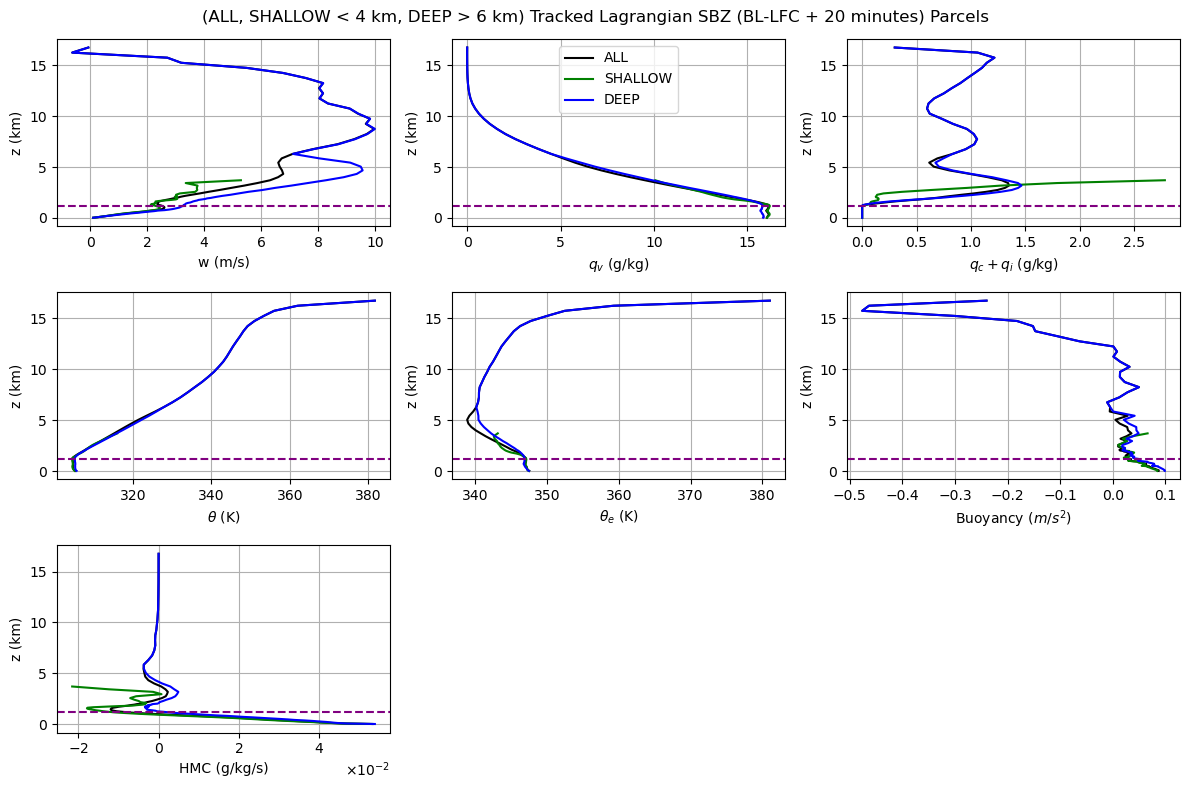

In [56]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

profiles = []
SE_profiles = []
for var, label in var_units:
    profiles.append((
        globals()[f"SBZ_ALL_profile_array_{var.upper()}"].copy(),
        globals()[f"SBZ_SHALLOW_profile_array_{var.upper()}"].copy(),
        globals()[f"SBZ_DEEP_profile_array_{var.upper()}"].copy(),
        label
    ))
    
    SE_profiles.append((
        globals()[f"SBZ_ALL_profile_array_SE_{var.upper()}"].copy(),
        globals()[f"SBZ_SHALLOW_profile_array_SE_{var.upper()}"].copy(),
        globals()[f"SBZ_DEEP_profile_array_SE_{var.upper()}"].copy(),
        None  # placeholder for xlabel not used in SE
    ))

# Set up the 2x3 gridspec
fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(3, 3, figure=fig)

# Loop through the profiles and plot them on subplots
# for i, (ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel) in enumerate(profiles):
for i, ((ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel), (ALL_SE, SHALLOW_SE, DEEP_SE, _)) in enumerate(zip(profiles, SE_profiles)):
    ax = fig.add_subplot(gs[i])
 
    # Plot Profiles
    profile_list=[ALL_profile_array,SHALLOW_profile_array,DEEP_profile_array]
    SE_profile_list=[ALL_SE,SHALLOW_SE,DEEP_SE]
    colors=['black','green','blue']
    labels=['ALL','SHALLOW','DEEP']
    # for (profile,color,label) in zip(profile_list,colors,labels):   
    for (profile,SE_profile,color,label) in zip(profile_list,SE_profile_list,colors,labels):   
        profile=averaged_profiles(profile) # Compute the averaged profile
        
        
        ################################################
        SE=averaged_profile_SE(SE_profile) #***
        switch=1
        if xlabel in [r'$q_v$ (g/kg)',r'$q_c+q_i$ (g/kg)','HMC (g/kg/s)']:
            profile[:,0]*=1000
            SE_profile[:,0]*=1000
            switch=0
        #STANDARD ERROR SHADING
        if SE_ARRAYS==True:
            ax.fill_betweenx(profile[:, 1], profile[:, 0] - 1.96*SE[0]*switch, profile[:, 0] + 1.96*SE[0], color=color, alpha=0.1) #***
        ################################################
        
        ax.plot(profile[:, 0], profile[:, 1],color=color,label=label)
        
    ax.set_xlabel(xlabel)
    ax.set_ylabel('z (km)')
    ax.grid(True)

    #LEGEND
    if i==1:
        ax.legend(loc='upper center')

    if i==6:
        apply_scientific_notation([ax])

    #LIMITING YAXIS TO BELOW 3 KM
    if limit_y==True: ax.set_ylim(0,3)

#MEAN CLOUD BASE
axs = fig.get_axes()
ax1, ax2, ax3, ax4, ax5, ax6, ax7 = axs
for axis in [ax1,ax2,ax3,ax4,ax5,ax6,ax7]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')
 
#LEGEND
# legend_ax = fig.add_subplot(gs[1, 2])  # Use the (2, 3) grid slot for the legend
# legend_ax.axis("off")  # Hide axes for the legend box
# legend_ax.legend(*ax.get_legend_handles_labels(), loc='center', frameon=False)

#ACCESSORIES
plt.suptitle('(ALL, SHALLOW < 4 km, DEEP > 6 km) Tracked Lagrangian SBZ (BL-LFC + 20 minutes) Parcels')
plt.tight_layout()

# #MATCHING X AXISES WITH NEXT PLOT
# #(TO KEEP AXISES CONSISTENT RUN PLOTS IN ORDER: 1st Plots, 2nd Plots, 1st Plots)
# for axis in axs:
#     nbins=7;axis.xaxis.set_major_locator(MaxNLocator(nbins=nbins))
# if 'ax8' in globals():
#     fix_x_limits([ax1,ax8])
#     fix_x_limits([ax2,ax9])
#     fix_x_limits([ax3,ax10])
#     fix_x_limits([ax4,ax11])
#     fix_x_limits([ax5,ax12])
#     fix_x_limits([ax6,ax13])
#     fix_x_limits([ax7,ax14])
#     del ax1,ax2,ax3,ax4,ax5,ax6,ax7,ax8,ax9,ax10,ax11,ax12,ax13,ax14


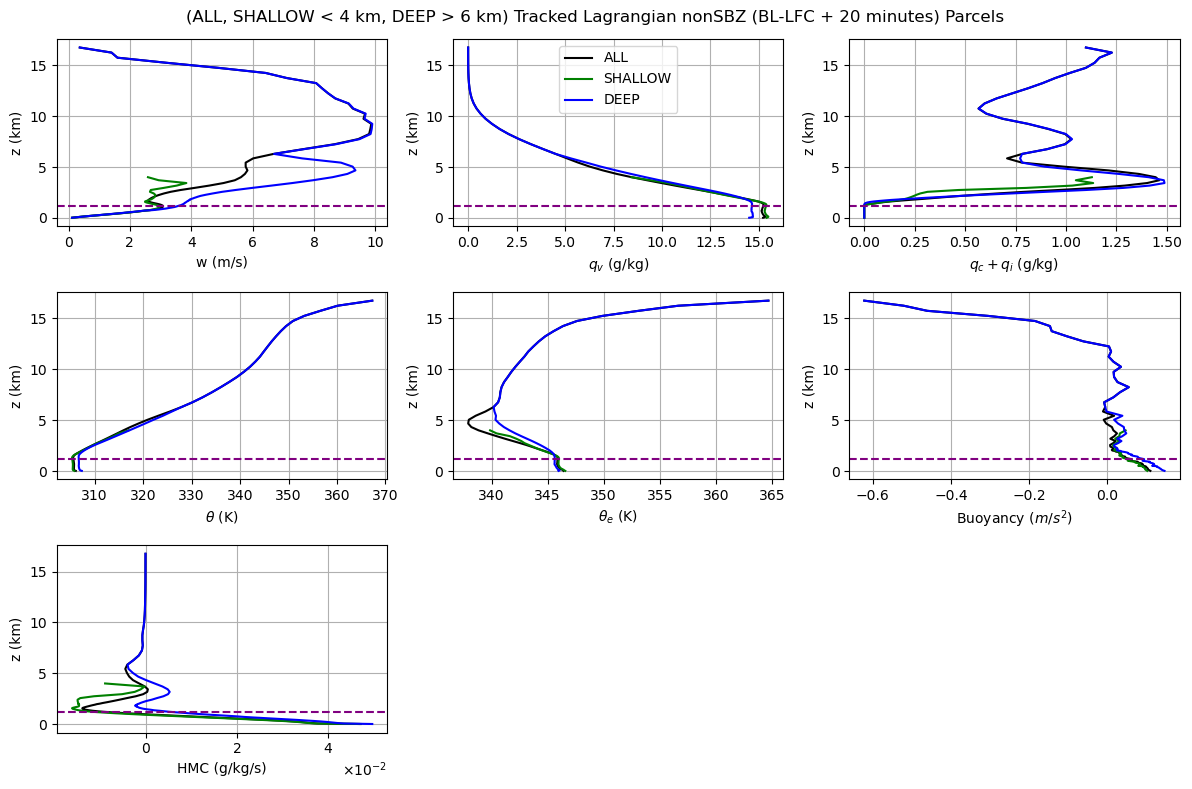

In [57]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

profiles = []
SE_profiles = []
for var, label in var_units:
    profiles.append((
        globals()[f"nonSBZ_ALL_profile_array_{var.upper()}"].copy(),
        globals()[f"nonSBZ_SHALLOW_profile_array_{var.upper()}"].copy(),
        globals()[f"nonSBZ_DEEP_profile_array_{var.upper()}"].copy(),
        label
    ))
    
    SE_profiles.append((
        globals()[f"nonSBZ_ALL_profile_array_SE_{var.upper()}"].copy(),
        globals()[f"nonSBZ_SHALLOW_profile_array_SE_{var.upper()}"].copy(),
        globals()[f"nonSBZ_DEEP_profile_array_SE_{var.upper()}"].copy(),
        None  # placeholder for xlabel not used in SE
    ))

# Set up the 2x3 gridspec
fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(3, 3, figure=fig)

# Loop through the profiles and plot them on subplots
# for i, (ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel) in enumerate(profiles):
for i, ((ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel), (ALL_SE, SHALLOW_SE, DEEP_SE, _)) in enumerate(zip(profiles, SE_profiles)):
    ax = fig.add_subplot(gs[i])
 
    # Plot Profiles
    profile_list=[ALL_profile_array,SHALLOW_profile_array,DEEP_profile_array]
    SE_profile_list=[ALL_SE,SHALLOW_SE,DEEP_SE]
    colors=['black','green','blue']
    labels=['ALL','SHALLOW','DEEP']
    # for (profile,color,label) in zip(profile_list,colors,labels):   
    for (profile,SE_profile,color,label) in zip(profile_list,SE_profile_list,colors,labels):   
        profile=averaged_profiles(profile) # Compute the averaged profile
        
        
        ################################################
        SE=averaged_profile_SE(SE_profile) #***
        switch=1
        if xlabel in [r'$q_v$ (g/kg)',r'$q_c+q_i$ (g/kg)','HMC (g/kg/s)']:
            profile[:,0]*=1000
            SE_profile[:,0]*=1000
            switch=0
        #STANDARD ERROR SHADING
        if SE_ARRAYS==True:
            ax.fill_betweenx(profile[:, 1], profile[:, 0] - 1.96*SE[0]*switch, profile[:, 0] + 1.96*SE[0], color=color, alpha=0.1) #***
        ################################################
        
        ax.plot(profile[:, 0], profile[:, 1],color=color,label=label)
        
    ax.set_xlabel(xlabel)
    ax.set_ylabel('z (km)')
    ax.grid(True)

    #LEGEND
    if i==1:
        ax.legend(loc='upper center')

    if i==6:
        apply_scientific_notation([ax])
        
    #LIMITING YAXIS TO BELOW 3 KM
    if limit_y==True: ax.set_ylim(0,3)

#MEAN CLOUD BASE
axs = fig.get_axes()
ax1, ax2, ax3, ax4, ax5, ax6, ax7 = axs
for axis in [ax1,ax2,ax3,ax4,ax5,ax6,ax7]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')
 
#LEGEND
# legend_ax = fig.add_subplot(gs[1, 2])  # Use the (2, 3) grid slot for the legend
# legend_ax.axis("off")  # Hide axes for the legend box
# legend_ax.legend(*ax.get_legend_handles_labels(), loc='center', frameon=False)

#ACCESSORIES
plt.suptitle('(ALL, SHALLOW < 4 km, DEEP > 6 km) Tracked Lagrangian nonSBZ (BL-LFC + 20 minutes) Parcels')
plt.tight_layout()

# #MATCHING X AXISES WITH NEXT PLOT
# #(TO KEEP AXISES CONSISTENT RUN PLOTS IN ORDER: 1st Plots, 2nd Plots, 1st Plots)
# for axis in axs:
#     nbins=7;axis.xaxis.set_major_locator(MaxNLocator(nbins=nbins))
# if 'ax8' in globals():
#     fix_x_limits([ax1,ax8])
#     fix_x_limits([ax2,ax9])
#     fix_x_limits([ax3,ax10])
#     fix_x_limits([ax4,ax11])
#     fix_x_limits([ax5,ax12])
#     fix_x_limits([ax6,ax13])
#     fix_x_limits([ax7,ax14])
#     del ax1,ax2,ax3,ax4,ax5,ax6,ax7,ax8,ax9,ax10,ax11,ax12,ax13,ax14


In [58]:
#SBZ vs nonSBZ
def average_difference(array1, array2):
    out_var_one=averaged_profiles(array1)
    out_var_two=averaged_profiles(array2)

    #masking out non matches
    second_col_one = out_var_one[:, 1]
    second_col_two = out_var_two[:, 1]
    mask_one = np.isin(second_col_one, second_col_two)
    mask_two = np.isin(second_col_two, second_col_one)
    
    out_var_one = out_var_one.copy()[mask_one]
    out_var_two = out_var_two.copy()[mask_two]
    
    diff=(out_var_one[:,0]-out_var_two[:,0])
    zs=out_var_one[:,1]

    out_profile=np.zeros((len(diff),2))

    out_profile[:,0]=diff;out_profile[:,1]=zs;
    return out_profile
    

var_names = [var[0] for var in var_units]
categories = ["ALL", "SHALLOW", "DEEP"]

for var in var_names:
    for cat in categories:
        # Construct the variable names dynamically
        CL_profile = globals()[f"SBZ_{cat}_profile_array_{var.upper()}"]
        nonCL_profile = globals()[f"nonSBZ_{cat}_profile_array_{var.upper()}"]
        
        # Calculate the difference and assign it to the global variable
        globals()[f"{cat}_diff_{var.upper()}"] = average_difference(CL_profile, nonCL_profile)
print('done')

done


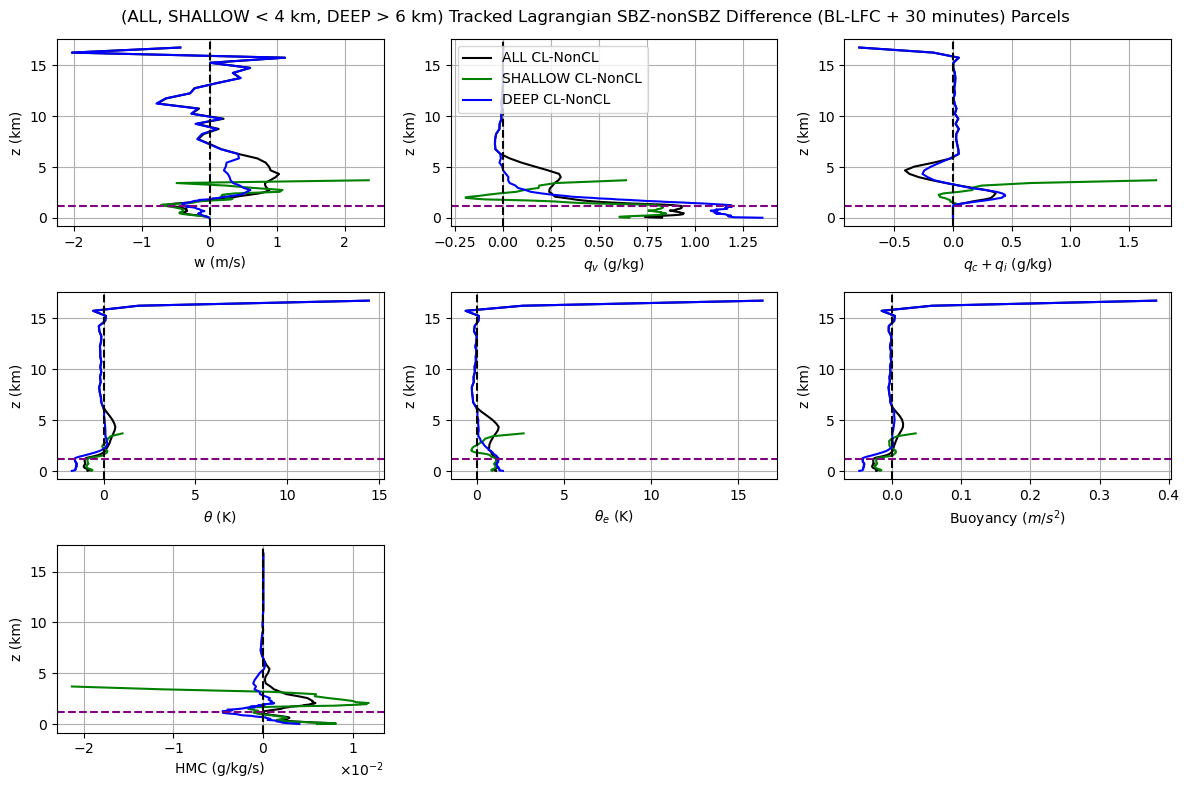

In [59]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Construct profiles dynamically using globals()
profiles = [
    (
        globals()[f"ALL_diff_{var.upper()}"].copy(),
        globals()[f"SHALLOW_diff_{var.upper()}"].copy(),
        globals()[f"DEEP_diff_{var.upper()}"].copy(),
        label
    )
    for var, label in var_units
]

# Set up the 2x3 gridspec
fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(3, 3, figure=fig)

# Loop through the profiles and plot them on subplots
for i, (ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel) in enumerate(profiles):
    ax = fig.add_subplot(gs[i])

    
    # Compute the averaged profile
    ALL_profile = ALL_profile_array.copy()
    SHALLOW_profile = SHALLOW_profile_array.copy()
    DEEP_profile = DEEP_profile_array.copy()

    if xlabel in [r'$q_v$ (g/kg)',r'$q_c+q_i$ (g/kg)','HMC (g/kg/s)']:
        ALL_profile[:,0]*=1000
        SHALLOW_profile[:,0]*=1000
        DEEP_profile[:,0]*=1000
    
    # Plot the profile
    ax.plot(ALL_profile[:, 0], ALL_profile[:, 1],color='black',label='ALL CL-NonCL')
    ax.plot(SHALLOW_profile[:, 0], SHALLOW_profile[:, 1],color='green',label='SHALLOW CL-NonCL')
    ax.plot(DEEP_profile[:, 0], DEEP_profile[:, 1],color='blue',label='DEEP CL-NonCL')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('z (km)')
    ax.grid(True)

    ax.axvline(0,color='k',linestyle='dashed')

    #LEGEND
    if i==1:
        ax.legend(loc='upper left')

    if i==6:
        apply_scientific_notation([ax])

    #LIMITING YAXIS TO BELOW 3 KM
    if limit_y==True: ax.set_ylim(0,3)


#MEAN CLOUD BASE
axs = fig.get_axes()
ax1, ax2, ax3, ax4, ax5, ax6, ax7 = axs
for axis in [ax1,ax2,ax3,ax4,ax5,ax6,ax7]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')
    
# #LEGEND
# legend_ax = fig.add_subplot(gs[1, 2])  # Use the (2, 3) grid slot for the legend
# legend_ax.axis("off")  # Hide axes for the legend box
# legend_ax.legend(*ax.get_legend_handles_labels(), loc='center', frameon=False)

#ACCESSORIES
plt.suptitle('(ALL, SHALLOW < 4 km, DEEP > 6 km) Tracked Lagrangian SBZ-nonSBZ Difference (BL-LFC + 30 minutes) Parcels')
plt.tight_layout()



In [60]:
#ColdPool
################################################################

In [61]:
#PLOTTING
############################################################

In [62]:
# #OLD
# #READING BACK IN

# types = ["ALL", "SHALLOW", "DEEP"]
# variables = ["W", "QV", "QCQI", "TH", "TH_E", "BUOYANCY", "HMC"]

# vars_list = []
# SE_list = []

# for t in types:
#     for var in variables:
#         vars_list.append(f"ColdPool_{t}_profile_array_{var.upper()}")
# # for t in types:
# #     for var in variables:
# #         SE_list.append(f"ColdPool_{t}_SE_{var.upper()}")
        
# # Define directory and output file path
# dir2=dir+'Project_Algorithms/Tracked_Profiles/job_out2/'
# # output_file=dir2+f"ColdPool_tracked_profiles_SE_{res}_{t_res}_{Np_str}.h5"
# output_file=dir2+f"ColdPool_tracked_profiles_{res}_{t_res}_{Np_str}.h5"

# # Open the HDF5 file and read the stored datasets into dynamically named variables
# with h5py.File(output_file, 'r') as f:
#     for var in vars_list:# + SE_list:
#         globals()[var] = f[f'{var.upper()}'][:]

In [63]:
type1='ColdPool'
dir3=dir+'Project_Algorithms/Tracked_Profiles/OUTPUT_FILES/'
filePath=dir3+f"{data_type}_"+f"{type1}_tracked_profiles_{res}_{t_res}_{Np_str}.h5"
with h5py.File(filePath, 'r') as h5f:
    for key in h5f.keys():
        globals()[key] = h5f[key][:]
        # print(key)

In [65]:
# type1='ColdPool'
# dir3=dir+'Project_Algorithms/Tracked_Profiles/OUTPUT_FILES/'
# filePath=dir3+f"{data_type}_"+f"{type1}_tracked_profiles_SE_{res}_{t_res}_{Np_str}.h5"
# with h5py.File(filePath, 'r') as h5f:
#     for key in h5f.keys():
#         globals()[key] = h5f[key][:]
#         # print(key)

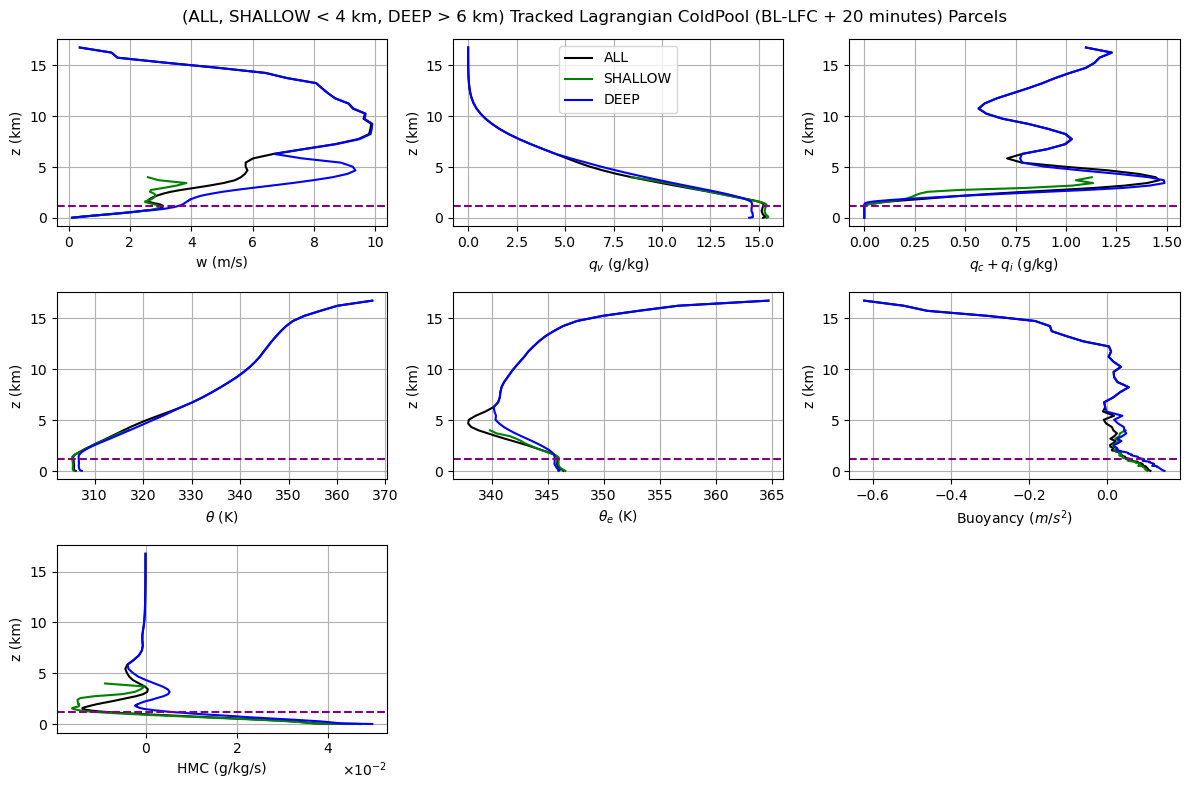

In [66]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

profiles = []
SE_profiles = []
for var, label in var_units:
    profiles.append((
        globals()[f"ColdPool_ALL_profile_array_{var.upper()}"].copy(),
        globals()[f"ColdPool_SHALLOW_profile_array_{var.upper()}"].copy(),
        globals()[f"ColdPool_DEEP_profile_array_{var.upper()}"].copy(),
        label
    ))
    
    SE_profiles.append((
        globals()[f"ColdPool_ALL_profile_array_SE_{var.upper()}"].copy(),
        globals()[f"ColdPool_SHALLOW_profile_array_SE_{var.upper()}"].copy(),
        globals()[f"ColdPool_DEEP_profile_array_SE_{var.upper()}"].copy(),
        None  # placeholder for xlabel not used in SE
    ))

# Set up the 2x3 gridspec
fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(3, 3, figure=fig)

# Loop through the profiles and plot them on subplots
# for i, (ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel) in enumerate(profiles):
for i, ((ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel), (ALL_SE, SHALLOW_SE, DEEP_SE, _)) in enumerate(zip(profiles, SE_profiles)):
    ax = fig.add_subplot(gs[i])
 
    # Plot Profiles
    profile_list=[ALL_profile_array,SHALLOW_profile_array,DEEP_profile_array]
    SE_profile_list=[ALL_SE,SHALLOW_SE,DEEP_SE]
    colors=['black','green','blue']
    labels=['ALL','SHALLOW','DEEP']
    # for (profile,color,label) in zip(profile_list,colors,labels):  
    for (profile,SE_profile,color,label) in zip(profile_list,SE_profile_list,colors,labels):   
        profile=averaged_profiles(profile) # Compute the averaged profile
        
        
        ################################################
        SE=averaged_profile_SE(SE_profile) #***
        switch=1
        if xlabel in [r'$q_v$ (g/kg)',r'$q_c+q_i$ (g/kg)','HMC (g/kg/s)']:
            profile[:,0]*=1000
            SE_profile[:,0]*=1000
            switch=0
        #STANDARD ERROR SHADING
        if SE_ARRAYS==True:
            ax.fill_betweenx(profile[:, 1], profile[:, 0] - 1.96*SE[0]*switch, profile[:, 0] + 1.96*SE[0], color=color, alpha=0.1) #***
        ################################################
        
        ax.plot(profile[:, 0], profile[:, 1],color=color,label=label)
        
    ax.set_xlabel(xlabel)
    ax.set_ylabel('z (km)')
    ax.grid(True)

    #LEGEND
    if i==1:
        ax.legend(loc='upper center')

    if i==6:
        apply_scientific_notation([ax])

    #LIMITING YAXIS TO BELOW 3 KM
    if limit_y==True: ax.set_ylim(0,3)

#MEAN CLOUD BASE
axs = fig.get_axes()
ax1, ax2, ax3, ax4, ax5, ax6, ax7 = axs
for axis in [ax1,ax2,ax3,ax4,ax5,ax6,ax7]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')
 
#LEGEND
# legend_ax = fig.add_subplot(gs[1, 2])  # Use the (2, 3) grid slot for the legend
# legend_ax.axis("off")  # Hide axes for the legend box
# legend_ax.legend(*ax.get_legend_handles_labels(), loc='center', frameon=False)

#ACCESSORIES
plt.suptitle('(ALL, SHALLOW < 4 km, DEEP > 6 km) Tracked Lagrangian ColdPool (BL-LFC + 20 minutes) Parcels')
plt.tight_layout()

# #MATCHING X AXISES WITH NEXT PLOT
# #(TO KEEP AXISES CONSISTENT RUN PLOTS IN ORDER: 1st Plots, 2nd Plots, 1st Plots)
# for axis in axs:
#     nbins=7;axis.xaxis.set_major_locator(MaxNLocator(nbins=nbins))
# if 'ax8' in globals():
#     fix_x_limits([ax1,ax8])
#     fix_x_limits([ax2,ax9])
#     fix_x_limits([ax3,ax10])
#     fix_x_limits([ax4,ax11])
#     fix_x_limits([ax5,ax12])
#     fix_x_limits([ax6,ax13])
#     fix_x_limits([ax7,ax14])
#     del ax1,ax2,ax3,ax4,ax5,ax6,ax7,ax8,ax9,ax10,ax11,ax12,ax13,ax14


In [67]:
#SBZ vs ColdPool
def average_difference(array1, array2):
    out_var_one=averaged_profiles(array1)
    out_var_two=averaged_profiles(array2)

    #masking out non matches
    second_col_one = out_var_one[:, 1]
    second_col_two = out_var_two[:, 1]
    mask_one = np.isin(second_col_one, second_col_two)
    mask_two = np.isin(second_col_two, second_col_one)
    
    out_var_one = out_var_one.copy()[mask_one]
    out_var_two = out_var_two.copy()[mask_two]
    
    diff=(out_var_one[:,0]-out_var_two[:,0])
    zs=out_var_one[:,1]

    out_profile=np.zeros((len(diff),2))

    out_profile[:,0]=diff;out_profile[:,1]=zs;
    return out_profile
    
# Calculate average differences for each variable (w, qv, qc, th, buoyancy) for ColdPool

var_names = [var[0] for var in var_units]
categories = ["ALL", "SHALLOW", "DEEP"]

for var in var_names:
    for cat in categories:
        # Construct the variable names dynamically
        CL_profile = globals()[f"SBZ_{cat}_profile_array_{var.upper()}"]
        nonCL_profile = globals()[f"ColdPool_{cat}_profile_array_{var.upper()}"]
        
        # Calculate the difference and assign it to the global variable
        globals()[f"{cat}_diff_{var.upper()}"] = average_difference(CL_profile, nonCL_profile)
print('done')

done


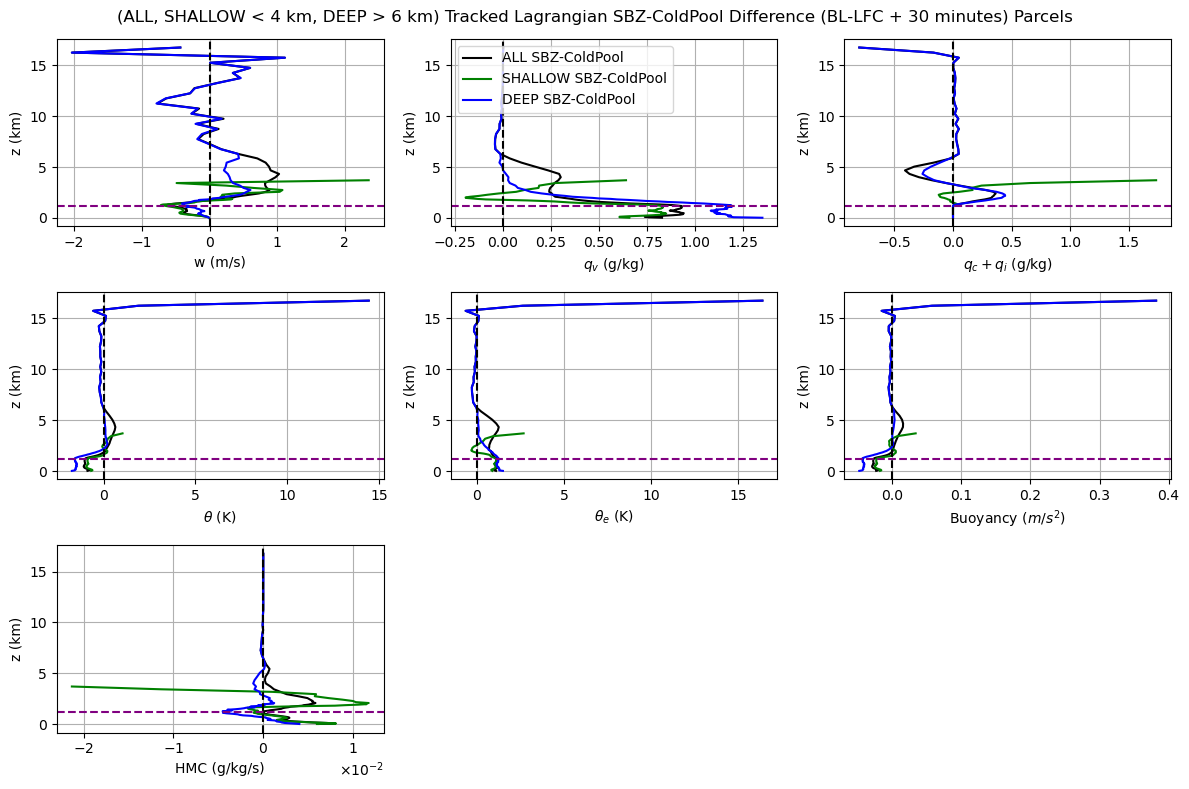

In [68]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Construct profiles dynamically using globals()
profiles = [
    (
        globals()[f"ALL_diff_{var.upper()}"].copy(),
        globals()[f"SHALLOW_diff_{var.upper()}"].copy(),
        globals()[f"DEEP_diff_{var.upper()}"].copy(),
        label
    )
    for var, label in var_units
]


# Set up the 2x3 gridspec
fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(3, 3, figure=fig)

# Loop through the profiles and plot them on subplots
for i, (ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel) in enumerate(profiles):
    ax = fig.add_subplot(gs[i])

    
    # Compute the averaged profile
    ALL_profile = ALL_profile_array.copy()
    SHALLOW_profile = SHALLOW_profile_array.copy()
    DEEP_profile = DEEP_profile_array.copy()

    if xlabel in [r'$q_v$ (g/kg)',r'$q_c+q_i$ (g/kg)','HMC (g/kg/s)']:
        ALL_profile[:,0]*=1000
        SHALLOW_profile[:,0]*=1000
        DEEP_profile[:,0]*=1000
    
    # Plot the profile
    ax.plot(ALL_profile[:, 0], ALL_profile[:, 1],color='black',label='ALL SBZ-ColdPool')
    ax.plot(SHALLOW_profile[:, 0], SHALLOW_profile[:, 1],color='green',label='SHALLOW SBZ-ColdPool')
    ax.plot(DEEP_profile[:, 0], DEEP_profile[:, 1],color='blue',label='DEEP SBZ-ColdPool')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('z (km)')
    ax.grid(True)

    ax.axvline(0,color='k',linestyle='dashed')

    if i==6:
        apply_scientific_notation([ax])

    #LEGEND
    if i==1:
        ax.legend(loc='upper left')

    #LIMITING YAXIS TO BELOW 3 KM
    if limit_y==True: ax.set_ylim(0,3)


#MEAN CLOUD BASE
axs = fig.get_axes()
ax1, ax2, ax3, ax4, ax5, ax6, ax7 = axs
for axis in [ax1,ax2,ax3,ax4,ax5,ax6,ax7]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')
    
# #LEGEND
# legend_ax = fig.add_subplot(gs[1, 2])  # Use the (2, 3) grid slot for the legend
# legend_ax.axis("off")  # Hide axes for the legend box
# legend_ax.legend(*ax.get_legend_handles_labels(), loc='center', frameon=False)

#ACCESSORIES
plt.suptitle('(ALL, SHALLOW < 4 km, DEEP > 6 km) Tracked Lagrangian SBZ-ColdPool Difference (BL-LFC + 30 minutes) Parcels')
plt.tight_layout()



In [141]:
################################################
#TESTING

In [99]:
# import matplotlib.pyplot as plt

# # Plot with double x-axis
# fig, ax1 = plt.subplots()

# # First x-axis for W
# test_var = CL_ALL_profile_array_W
# out1 = averaged_profiles(test_var)
# line1, = ax1.plot(out1[:, 0], out1[:, 1], 'k-', label='W (m/s)')
# ax1.set_xlabel('W (m/s)', color='k')
# ax1.set_ylabel('z (km)')
# ax1.tick_params(axis='x', labelcolor='k')

# # Twin x-axis for QI and QCQI
# #1
# ax2 = ax1.twiny()
# test_var = CL_ALL_profile_array_QI
# out2 = averaged_profiles(test_var)
# line2, = ax2.plot(out2[:, 0]*1000, out2[:, 1], 'b-', label='QI (g/kg)')
# #2
# test_var = CL_ALL_profile_array_QCQI
# out3 = averaged_profiles(test_var)
# line3, = ax2.plot(out3[:, 0]*1000, out3[:, 1], 'b--', label='QC+QI (g/kg)')
# ax2.set_xlabel('Q (g/kg)', color='b')
# ax2.tick_params(axis='x', labelcolor='b')
# #3
# test_var = CL_ALL_profile_array_QR
# out3 = averaged_profiles(test_var)
# line3, = ax2.plot(out3[:, 0]*1000, out3[:, 1], 'g-', label='QR (g/kg)')
# ax2.tick_params(axis='x', labelcolor='b')

# # Combine all lines for a single legend
# lines = [line1, line2, line3]
# labels = [line.get_label() for line in lines]

# plt.title('ALL CL Tracked Profiles: W and QI (and QCQI) vs z')
# plt.legend(lines, labels, loc='lower right')  # Adjust loc as needed
# plt.show()


In [100]:
# import matplotlib.pyplot as plt

# # Plot with double x-axis
# fig, ax1 = plt.subplots()

# # First x-axis for W
# test_var = CL_ALL_profile_array_BUOYANCY
# out1 = averaged_profiles(test_var)
# line1, = ax1.plot(out1[:, 0], out1[:, 1], 'k-', label='W (m/s)')
# ax1.set_xlabel('W (m/s)', color='k')
# ax1.set_ylabel('z (km)')
# ax1.tick_params(axis='x', labelcolor='k')

# # Twin x-axis for QI and QCQI
# ax2 = ax1.twiny()
# test_var = CL_ALL_profile_array_TH_E
# out2 = averaged_profiles(test_var)
# line2, = ax2.plot(out2[:, 0], out2[:, 1], 'b-', label='QI (g/kg)')

# ax2.set_xlabel('TH (K)', color='b')
# ax2.tick_params(axis='x', labelcolor='b')

# # Combine all lines for a single legend
# lines = [line1, line2, line3]
# labels = [line.get_label() for line in lines]

# plt.title('ALL CL Tracked Profiles: BUOYANCY and TH vs z')
# plt.legend(lines, labels, loc='lower center')  # Adjust loc as needed
# plt.show()
